In [133]:
import requests
import json
from datetime import datetime, timedelta, timezone
from datetime import timezone
import time
import random
import asyncio, aiohttp
import matplotlib.pyplot as plt
from collections import defaultdict

_TOKEN_CACHE = None  # global cache

def get_session_token():
    global _TOKEN_CACHE
    if _TOKEN_CACHE:   # reuse valid token
        return _TOKEN_CACHE

    url = "https://bsky.social/xrpc/com.atproto.server.createSession"
    handle = "repostproj.bsky.social"
    app_password = "vyvc-xg5q-seda-utaz" 

    for _ in range(3):  # retry a few times on rate limit
        r = requests.post(url, json={"identifier": handle, "password": app_password})
        if r.status_code == 429:
            print("⚠️ Rate-limited on login, sleeping 5s...")
            time.sleep(1)
            continue
        r.raise_for_status()
        _TOKEN_CACHE = r.json()["accessJwt"]
        return _TOKEN_CACHE

    raise RuntimeError("Failed to obtain token after retries")


In [191]:



def fmt(dt):
    """Convert datetime → Bluesky timestamp format."""
    if dt.tzinfo is None:
        dt = dt.replace(tzinfo=timezone.utc)
    return dt.strftime("%Y-%m-%dT%H:%M:%S.000Z")


def parse_dt(created):
    """Parse Bluesky createdAt → naive UTC datetime."""
    return (
        datetime.fromisoformat(created.replace("Z", "+00:00"))
        .astimezone(timezone.utc)
        .replace(tzinfo=None)
    )


def fetch_posts(
    query,
    since_dt,
    until_dt,
    outfile,
    max_posts=None,
    min_posts=0
):
    """
    Fetch ALL posts the Bluesky index returns between since_dt and until_dt.
    Continues by stepping `until` backward using the oldest timestamp.
    Raises ValueError if fewer than min_posts are collected.
    """

    url = "https://bsky.social/xrpc/app.bsky.feed.searchPosts"
    token = get_session_token()

    headers = {"Authorization": f"Bearer {token}"}

    current_until = until_dt
    total = 0
    last_print = 0

    with open(outfile, "w", encoding="utf-8") as f:

        while True:
            params = {
                "q": query,
                "limit": 100,
                "sort": "latest",
                "since": fmt(since_dt),
                "until": fmt(current_until),
            }

            r = requests.get(url, headers=headers, params=params)

            if r.status_code in (429, 502):
                time.sleep(1)
                continue

            if r.status_code != 200:
                break

            data = r.json()
            posts = data.get("posts", [])

            if not posts:
                break

            for p in posts:
                f.write(json.dumps(p, ensure_ascii=False) + "\n")
                total += 1

                if total - last_print >= 2000:
                    print(f"\rCollected {total} posts so far…", end="", flush=True)
                    last_print = total

                if max_posts and total >= max_posts:
                    break

            oldest_ts = posts[-1]["record"]["createdAt"]
            oldest_dt = parse_dt(oldest_ts)

            if oldest_dt <= since_dt or (max_posts and total >= max_posts):
                break

            current_until = oldest_dt

    if total < min_posts:
        raise ValueError(
            f"Query '{query}' returned only {total} posts "
            f"(minimum required: {min_posts})"
        )

    return total

def collect_hashtags_posts(
    hashtags,
    since_dt,
    until_dt,
    max_posts_per_hashtag,
    min_posts_per_hashtag
):
    for h in hashtags:
        file = f"{h}.jsonl"
        query = f"#{h}"

        fetch_posts(
            query=query,
            since_dt=since_dt,
            until_dt=until_dt,
            outfile=file,
            max_posts=max_posts_per_hashtag,
            min_posts=min_posts_per_hashtag
        )



In [198]:
# Trump Minneapolis TikTok GoldenGlobes NBA AI TheTraitors booksky gaza tennis aew releasetheepsteinfiles
collect_hashtags_posts(
    hashtags= ["aew","releasetheepsteinfiles","TikTok"],
    since_dt=datetime(2025, 12, 1),
    until_dt=datetime(2026, 1, 30),
    max_posts_per_hashtag = 20000,
    min_posts_per_hashtag = 8000
)

Collected 8000 posts so far……

In [ ]:
file = 'releasetheepsteinfiles.jsonl'

In [184]:


def get_post_day_stats():
    stats = defaultdict(lambda: {
        "count": 0,
        "min_hour": None,
        "max_hour": None,
        "total_reposts": 0,
        "avg_reposts_per_post": 0.0
    })

    with open(file, "r", encoding="utf-8") as f:
        for line in f:
            try:
                p = json.loads(line)
            except json.JSONDecodeError:
                continue

            created = (p.get("record") or {}).get("createdAt")
            if not created:
                continue

            try:
                dt = datetime.fromisoformat(created.replace("Z", "+00:00"))
            except Exception:
                try:
                    dt = datetime.fromisoformat(created[:19])
                except Exception:
                    continue

            day = dt.date().isoformat()
            hour = dt.hour

            stats[day]["count"] += 1
            stats[day]["total_reposts"] += p.get("repostCount", 0) or 0

            if stats[day]["min_hour"] is None or hour < stats[day]["min_hour"]:
                stats[day]["min_hour"] = hour

            if stats[day]["max_hour"] is None or hour > stats[day]["max_hour"]:
                stats[day]["max_hour"] = hour

    # Print results (sorted by day)
    for day in sorted(stats):
        d = stats[day]
        avg = round(d["total_reposts"] / d["count"], 2) if d["count"] > 0 else 0.0

        print(
            f"{day} | "
            f"posts={d['count']} | "
            f"hours={d['min_hour']}-{d['max_hour']} | "
            f"total_reposts={d['total_reposts']} | "
            f"avg_reposts_per_post={avg}"
        )

    return

get_post_day_stats()

2026-01-19 | posts=195 | hours=13-23 | total_reposts=189 | avg_reposts_per_post=0.97
2026-01-20 | posts=455 | hours=0-23 | total_reposts=650 | avg_reposts_per_post=1.43
2026-01-21 | posts=423 | hours=0-23 | total_reposts=458 | avg_reposts_per_post=1.08
2026-01-22 | posts=351 | hours=0-23 | total_reposts=455 | avg_reposts_per_post=1.3
2026-01-23 | posts=351 | hours=0-23 | total_reposts=364 | avg_reposts_per_post=1.04
2026-01-24 | posts=413 | hours=0-23 | total_reposts=406 | avg_reposts_per_post=0.98
2026-01-25 | posts=430 | hours=0-23 | total_reposts=867 | avg_reposts_per_post=2.02
2026-01-26 | posts=340 | hours=0-23 | total_reposts=507 | avg_reposts_per_post=1.49
2026-01-27 | posts=359 | hours=0-23 | total_reposts=793 | avg_reposts_per_post=2.21
2026-01-28 | posts=331 | hours=0-23 | total_reposts=470 | avg_reposts_per_post=1.42
2026-01-29 | posts=352 | hours=0-23 | total_reposts=299 | avg_reposts_per_post=0.85


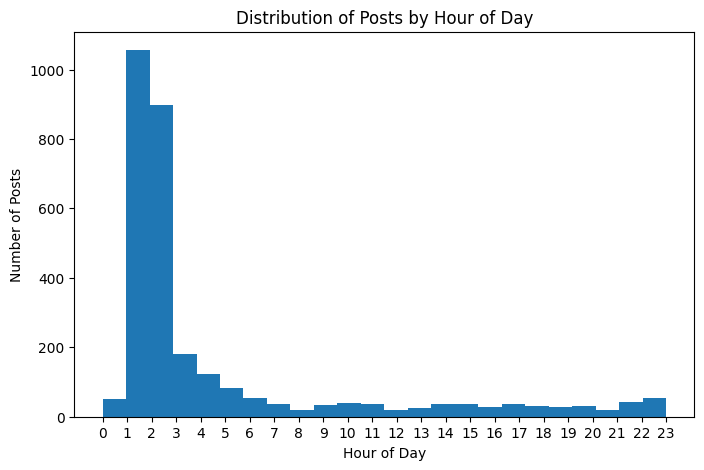

In [180]:



def plot_posts_by_hour(file_path):
    """
    Reads a .jsonl file of Bluesky posts and plots:
        Number of posts  vs  Hour of the day (0–23)
    """
    hours = []

    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            try:
                post = json.loads(line)
            except json.JSONDecodeError:
                continue

            created = (post.get("record") or {}).get("createdAt")
            if not created:
                continue

            # Parse timestamp safely
            try:
                dt = datetime.fromisoformat(created.replace("Z", "+00:00"))
            except:
                try:
                    dt = datetime.fromisoformat(created[:19])
                except:
                    continue

            hours.append(dt.hour)

    # Plot
    plt.figure(figsize=(8,5))
    plt.hist(hours, bins=24)
    plt.xlabel("Hour of Day")
    plt.ylabel("Number of Posts")
    plt.title("Distribution of Posts by Hour of Day")
    plt.xticks(range(24))
    plt.show()

plot_posts_by_hour(file)


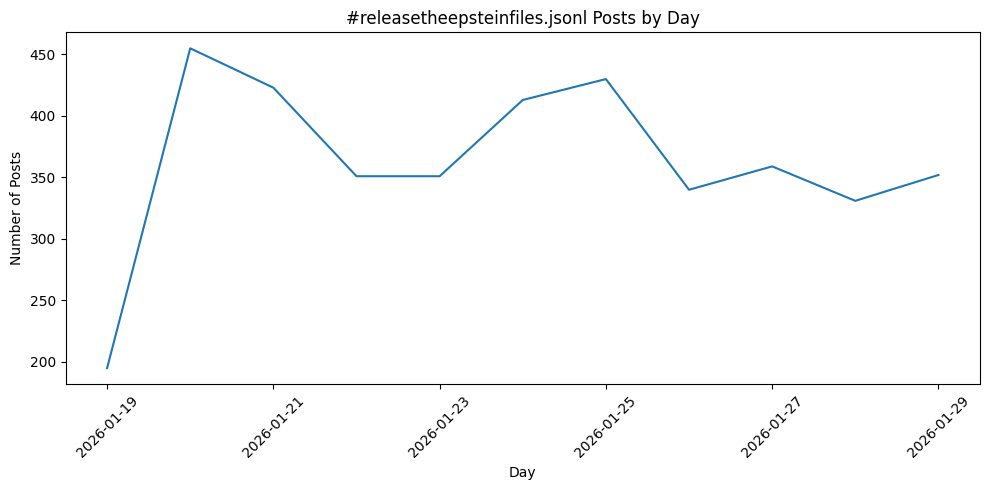

In [185]:

from collections import Counter


def plot_posts_by_day(file_path):
    """
    Reads a .jsonl file of Bluesky posts and plots:
        Number of posts vs Day
    """
    dates = []

    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            try:
                post = json.loads(line)
            except json.JSONDecodeError:
                continue

            created = (post.get("record") or {}).get("createdAt")
            if not created:
                continue

            # Parse timestamp safely
            try:
                dt = datetime.fromisoformat(created.replace("Z", "+00:00"))
            except:
                try:
                    dt = datetime.fromisoformat(created[:19])
                except:
                    continue

            dates.append(dt.date())

    # Count posts per day
    counts = Counter(dates)
    days = sorted(counts.keys())
    values = [counts[d] for d in days]

    # Plot
    plt.figure(figsize=(10,5))
    plt.plot(days, values)
    plt.xlabel("Day")
    plt.ylabel("Number of Posts")
    plt.title(f"#{file_path} Posts by Day")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_posts_by_day(file)
